In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
gpp.set_aesthetics(context = 'paper')
from scipy.stats import fisher_exact

In [2]:
#read in cleaned labeled dolcetto nonessentials
noness_labeled = pd.read_csv('../../Data/externalData/Dolcetto/dolcetto_seed_score_validation_input_a375_ht29_average_with_intergenics.csv')

In [3]:
def count_overlapping_matches(seq,pattern):
    count = 0
    length = len(pattern)
    for i in range(len(seq)-1):
        if seq[i:(i+length)] == pattern:
            count +=1
    return count

In [4]:
n_list = ['A','T','C','G']
din_list = []
for n1 in n_list:
    for n2 in n_list:
        din_list.append(n1+n2)

In [5]:
#create separate column with seed sequence
noness_labeled.loc[:,'seed_seq'] = noness_labeled['sgRNA Sequence'].str[-12:]
#create column for every nucleotide containing number of occurrences within the seed sequence
for din in din_list:
    noness_labeled.loc[:,din] = noness_labeled.loc[:,'seed_seq'].apply(lambda seq: count_overlapping_matches(seq,din))

In [6]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')
#bin dinucleotide occurrences to aggregate counts >=2 into one category (for plotting)
bins = [0,1,2,3,np.inf]
labels = ['0','1','2','>2']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()


#only consider combinations with at least 30 guides
plot_df = plot_df[plot_df['group_size'] >= 30].copy()

#pivot df to allow to be plotted as heatmap
plot_df = plot_df.pivot(columns = ['Dinucleotide'], index = 'num_occurrence_bin',
              values = 'prop_promiscuous')
plot_df = plot_df.sort_values(by = ['>2'], axis=1, ascending=False)
plot_df

Dinucleotide,GG,CT,AG,CC,GA,CG,GC,TC,AC,CA,TG,AA,AT,GT,TT,TA
num_occurrence_bin,,,,,,,,,,,,,,,,
0,0.014797,0.029225,0.014840,0.017054,0.023351,0.019555,0.017391,0.028340,0.024806,0.030204,0.031526,0.031095,0.037670,0.032292,0.032648,0.025986
1,0.012893,0.014403,0.024288,0.028708,0.018913,0.028868,0.034608,0.021240,0.026163,0.026056,0.023887,0.015337,0.006871,0.014211,0.007184,0.021603
2,0.028571,0.012146,0.025105,0.019780,0.032289,0.068627,0.017606,0.016766,0.013353,0.012225,0.007423,0.021851,0.000000,0.007005,0.000000,0.007380
>2,0.132867,0.098485,0.068681,0.057312,0.047210,0.034483,0.015385,0.011834,0.010638,0.006601,0.004651,0.002083,0.000000,0.000000,0.000000,NaN


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, '0'), Text(0, 1.5, '1'), Text(0, 2.5, '2'), Text(0, 3.5, '>2')])

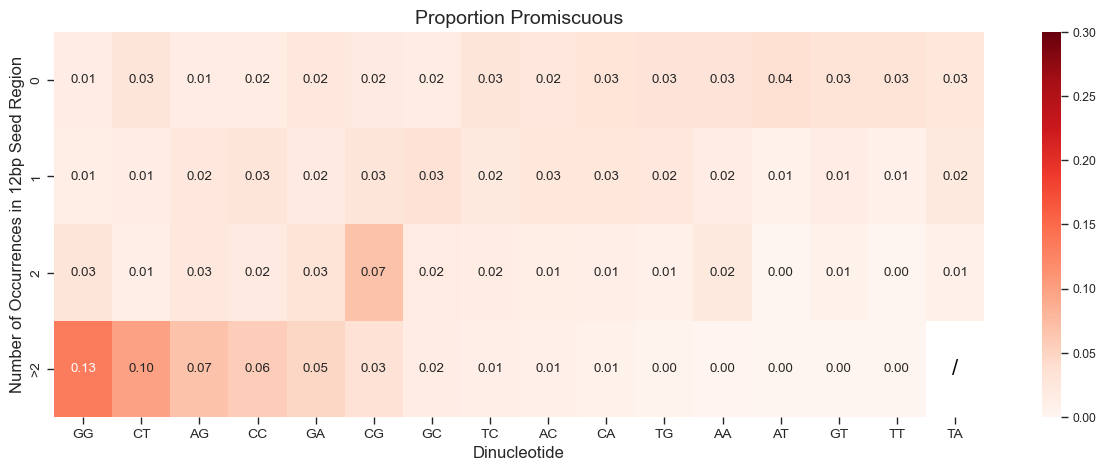

In [7]:
plt.figure(figsize=(15,5))
ax = sns.heatmap(plot_df,cmap='Reds',
               vmin=0, vmax=0.3, annot=True, fmt = '0.2f')
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        if np.isnan(plot_df.iloc[i, j]):
            ax.text(j + 0.5, i + 0.5, "/", ha='center', va='center', color='black', fontsize=16)
plt.xlabel('Dinucleotide',fontsize=12)
plt.ylabel('Number of Occurrences in 12bp Seed Region',fontsize=12)
plt.title('Proportion Promiscuous', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

In [8]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')

#if we considered all guides with >=0 counts of a certain dinucleotide, we would simply be considering every guide in the dataset
plot_df = plot_df[plot_df['num_occurrences'] > 0].copy()

#bin dinucleotide occurrences to aggregate counts >=3 into one category (for plotting)
bins = [1,2,3,4,np.inf]
labels = ['>=1','>=2','>=3','>=4']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()

#calculate number of guides / promiscuous guides with AT LEAST a certain count of each dinucleotide
plot_df['cumsum_promiscuous'] = plot_df[::-1].groupby('Dinucleotide')['sum_promiscuous'].transform('cumsum')
plot_df['cum_group_size'] = plot_df[::-1].groupby('Dinucleotide')['group_size'].transform('cumsum')

#recalculate proportion of promiscuous guides
plot_df['cumprop_promiscuous'] = plot_df['cumsum_promiscuous']/plot_df['cum_group_size']


#only consider groups with at least 30 guides for consistency with previous plot
plot_df = plot_df[plot_df['cum_group_size'] >= 30].copy()


#implement Fisher Exact test

total_promiscuous = noness_labeled['promiscuous'].sum()
total_nonpromiscuous = (~noness_labeled['promiscuous']).sum()
plot_df.loc[:,'p_value'] = plot_df.apply(lambda row: fisher_exact(np.array([[row['cumsum_promiscuous'],row['cum_group_size']-row['cumsum_promiscuous']],
                                                                  [total_promiscuous,total_nonpromiscuous]]),
                                         alternative = 'greater').pvalue, axis=1)
plot_df.loc[:,'-log(p-value)'] = -np.log10(plot_df.loc[:,'p_value'])

plot_df

,Dinucleotide,num_occurrence_bin,prop_promiscuous,sum_promiscuous,group_size,cumsum_promiscuous,cum_group_size,cumprop_promiscuous,p_value,-log(p-value)
0,AA,>=1,0.015337,25,1630,43,2888,0.014889,9.985217e-01,6.424875e-04
1,AA,>=2,0.021851,17,778,18,1258,0.014308,9.899332e-01,4.394125e-03
2,AA,>=3,0.003096,1,323,1,480,0.002083,9.999874e-01,5.481779e-06
3,AA,>=4,0.000000,0,157,0,157,0.000000,1.000000e+00,-0.000000e+00
4,AC,>=1,0.026163,63,2408,73,3176,0.022985,6.363113e-01,1.963304e-01
5,AC,>=2,0.013353,9,674,10,768,0.013021,9.852440e-01,6.456201e-03
6,AC,>=3,0.011494,1,87,1,94,0.010638,8.970756e-01,4.717097e-02
8,AG,>=1,0.024288,64,2635,125,4433,0.028198,9.237163e-02,1.034461e+00
9,AG,>=2,0.025105,36,1434,61,1798,0.033927,1.321999e-02,1.878769e+00
10,AG,>=3,0.064815,21,324,25,364,0.068681,8.266961e-06,5.082654e+00


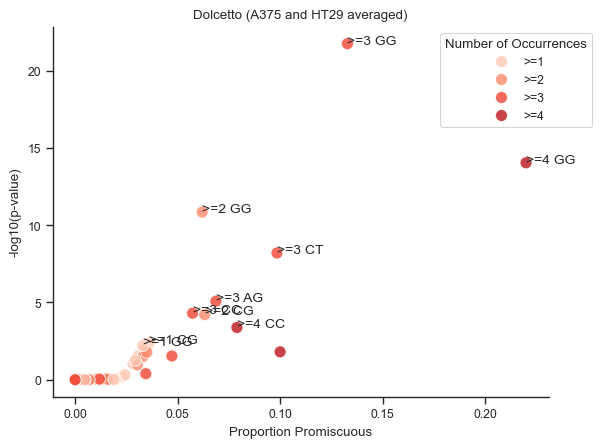

In [9]:
sns.scatterplot(data = plot_df, x = 'cumprop_promiscuous', y = '-log(p-value)', hue = 'num_occurrence_bin',
                palette='Reds', alpha = 0.8, s = 75)

texts = []
for i,row in plot_df.iterrows():
    x = row['cumprop_promiscuous']
    y = row['-log(p-value)']
    din = str(row['Dinucleotide'])
    n = str(row['num_occurrence_bin'])
    if (y > 2):
        text = plt.text(x, y, n + ' ' + din, fontsize=10)
sns.despine()

plt.xlabel('Proportion Promiscuous')
plt.ylabel('-log10(p-value)')
plt.legend(title = 'Number of Occurrences', bbox_to_anchor=(1.1,1))
plt.title('Dolcetto (A375 and HT29 averaged)')

gpp.savefig("../../Figures/Figure 5/dolcetto_nonessentials_12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.pdf",
            dpi=300,
            bbox_inches = 'tight')
gpp.savefig("../../Figures/Figure 5/dolcetto_nonessentials_12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.png",
            dpi=300,
            bbox_inches = 'tight')

In [158]:
plot_df[plot_df['num_occurrence_bin'] == '>=4']

,Dinucleotide,num_occurrence_bin,prop_promiscuous,sum_promiscuous,group_size,cumsum_promiscuous,cum_group_size,cumprop_promiscuous,p_value,-log(p-value)
3,AA,>=4,0.000000,0,157,0,157,0.000000,1.000000e+00,-0.000000
11,AG,>=4,0.100000,4,40,4,40,0.100000,1.572834e-02,1.803317
23,CC,>=4,0.078947,12,152,12,152,0.078947,4.185423e-04,3.378261
43,GG,>=4,0.220000,22,100,22,100,0.220000,9.171497e-15,14.037560
